In [57]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy

def std(x):return unp.std_devs(x)
def nom(x):return unp.nominal_values(x)
def arrayu_to_uarray(x):
    return unp.uarray([a.nominal_value for a in x],[a.std_dev for a in x])


Abgelesener Nullpunkt: -268.2+/-1.3


<ErrorbarContainer object of 3 artists>

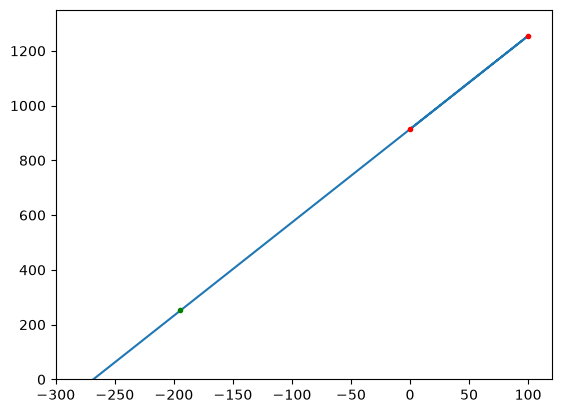

In [73]:
P_raum = ufloat(1007.8,0.1)
P_normal = 1013.25
Eich_Druck_1 = arrayu_to_uarray([ufloat(914,1),ufloat(1248,1) * P_normal/P_raum])


Eich_Temp_1 = [0,100]

plt.errorbar(Eich_Temp_1,nom(Eich_Druck_1), yerr=std(Eich_Druck_1),fmt="r.")

intercept  = Eich_Temp_1[0] - Eich_Druck_1[0] * (Eich_Temp_1[1] - Eich_Temp_1[0]) / (Eich_Druck_1[1] - Eich_Druck_1[0])
print("Abgelesener Nullpunkt:" ,intercept)
plt.plot(Eich_Temp_1 + [intercept.nominal_value], list(nom(Eich_Druck_1)) + [0])
plt.xlim(-300,120)
#plt.xlim(-200,-180)
plt.ylim(0,1350)
#plt.ylim(200,300)


P_N = 255  # Stickstoff
T_N_abgelesen = -194.4
plt.errorbar([T_N_abgelesen], [P_N],fmt="g.")

Abgelesener Nullpunkt: 0.04431194761343704


(0.0, 1350.0)

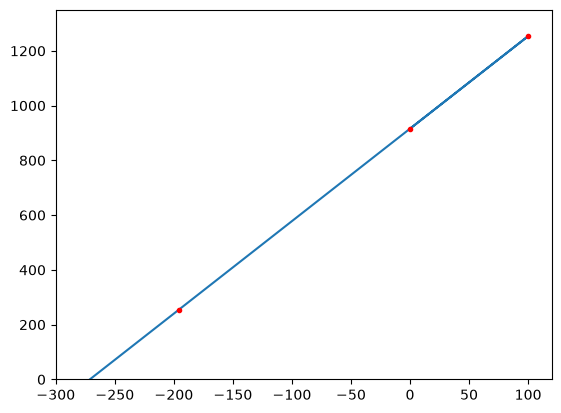

In [74]:
# Eichkurve mit drei Punkten


P_raum = ufloat(1007.8,0.1)
P_normal = 1013.25
Eich_Druck_1 = arrayu_to_uarray([ufloat(914,1),ufloat(1248,1) * P_normal/P_raum,ufloat(255,1)])


Eich_Temp_1 = np.array([0,100,-195.8])

plt.errorbar(Eich_Temp_1,nom(Eich_Druck_1), yerr=std(Eich_Druck_1),fmt="r.")

def linear_func(x, a, b): return a*x + b

fit, _ = scipy.optimize.curve_fit(linear_func,Eich_Temp_1, nom(Eich_Druck_1))

x = np.append(Eich_Temp_1,-273)

plt.plot(x,linear_func(x,fit[0],fit[1]))

T_0_abgelesen = -271.1 # Abgelesener Nullpunkt
print("Abgelesener Nullpunkt:" , linear_func(T_0_abgelesen,fit[0],fit[1]))

plt.xlim(-300,120)
#plt.xlim(-200,-180)
plt.ylim(0,1350)
#plt.ylim(200,300)

